In [ ]:
import os
import math
import datetime
from tqdm import tqdm
import pandas as pd
import numpy as np
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib import rc
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]

sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))

rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [7]:
train = pd.read_csv("Train Data.csv")
valid = pd.read_csv("Valid Data.csv")
test = pd.read_csv("Test Data.csv")

In [9]:
train.head(10)

,text,intent
0,listen to westbam alumb allergic on google music,PlayMusic
1,add step to me to the 50 clásicos playlist,AddToPlaylist
2,i give this current textbook a rating value of...,RateBook
3,play the song little robin redbreast,PlayMusic
4,please add iris dement to my playlist this is ...,AddToPlaylist
5,add slimm cutta calhoun to my this is prince p...,AddToPlaylist
6,i want to listen to seventies music,PlayMusic
7,play a popular chant by brian epstein,PlayMusic
8,find fish story,SearchScreeningEvent
9,book a spot for 3 in mt,BookRestaurant


In [10]:
test.head(10)

,text,intent
0,add sabrina salerno to the grime instrumentals...,AddToPlaylist
1,i want to bring four people to a place that s ...,BookRestaurant
2,put lindsey cardinale into my hillary clinton ...,AddToPlaylist
3,will it snow in mt on june 13 2038,GetWeather
4,play signe anderson chant music that is newest,PlayMusic
5,can you let me know what animated movies are p...,SearchScreeningEvent
6,can you get me reservations for a highly rated...,BookRestaurant
7,what s the weather here on 2/7/2021,GetWeather
8,find worldly goods starting now at a movie house,SearchScreeningEvent
9,on june 27 2026 i d like to go to a delaware ...,BookRestaurant


In [11]:
valid.head(10)

,text,intent
0,i d like to have this track onto my classical ...,AddToPlaylist
1,add the album to my flow español playlist,AddToPlaylist
2,add digging now to my young at heart playlist,AddToPlaylist
3,add this song by too poetic to my piano ballad...,AddToPlaylist
4,add this album to old school death metal,AddToPlaylist
5,i need to add baro ferret to the urban hits un...,AddToPlaylist
6,add the album to the might and myth power meta...,AddToPlaylist
7,to the travelling playlist please add this da...,AddToPlaylist
8,please add some pete townshend to my playlist ...,AddToPlaylist
9,i d like for kasey chambers s tune to be an ad...,AddToPlaylist


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13084 entries, 0 to 13083
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    13084 non-null  object
 1   intent  13084 non-null  object
dtypes: object(2)
memory usage: 204.6+ KB


/var/folders/9c/h1vdj_9x2kg1_99d25730yd80000gn/T/ipykernel_40662/1538350227.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.countplot(


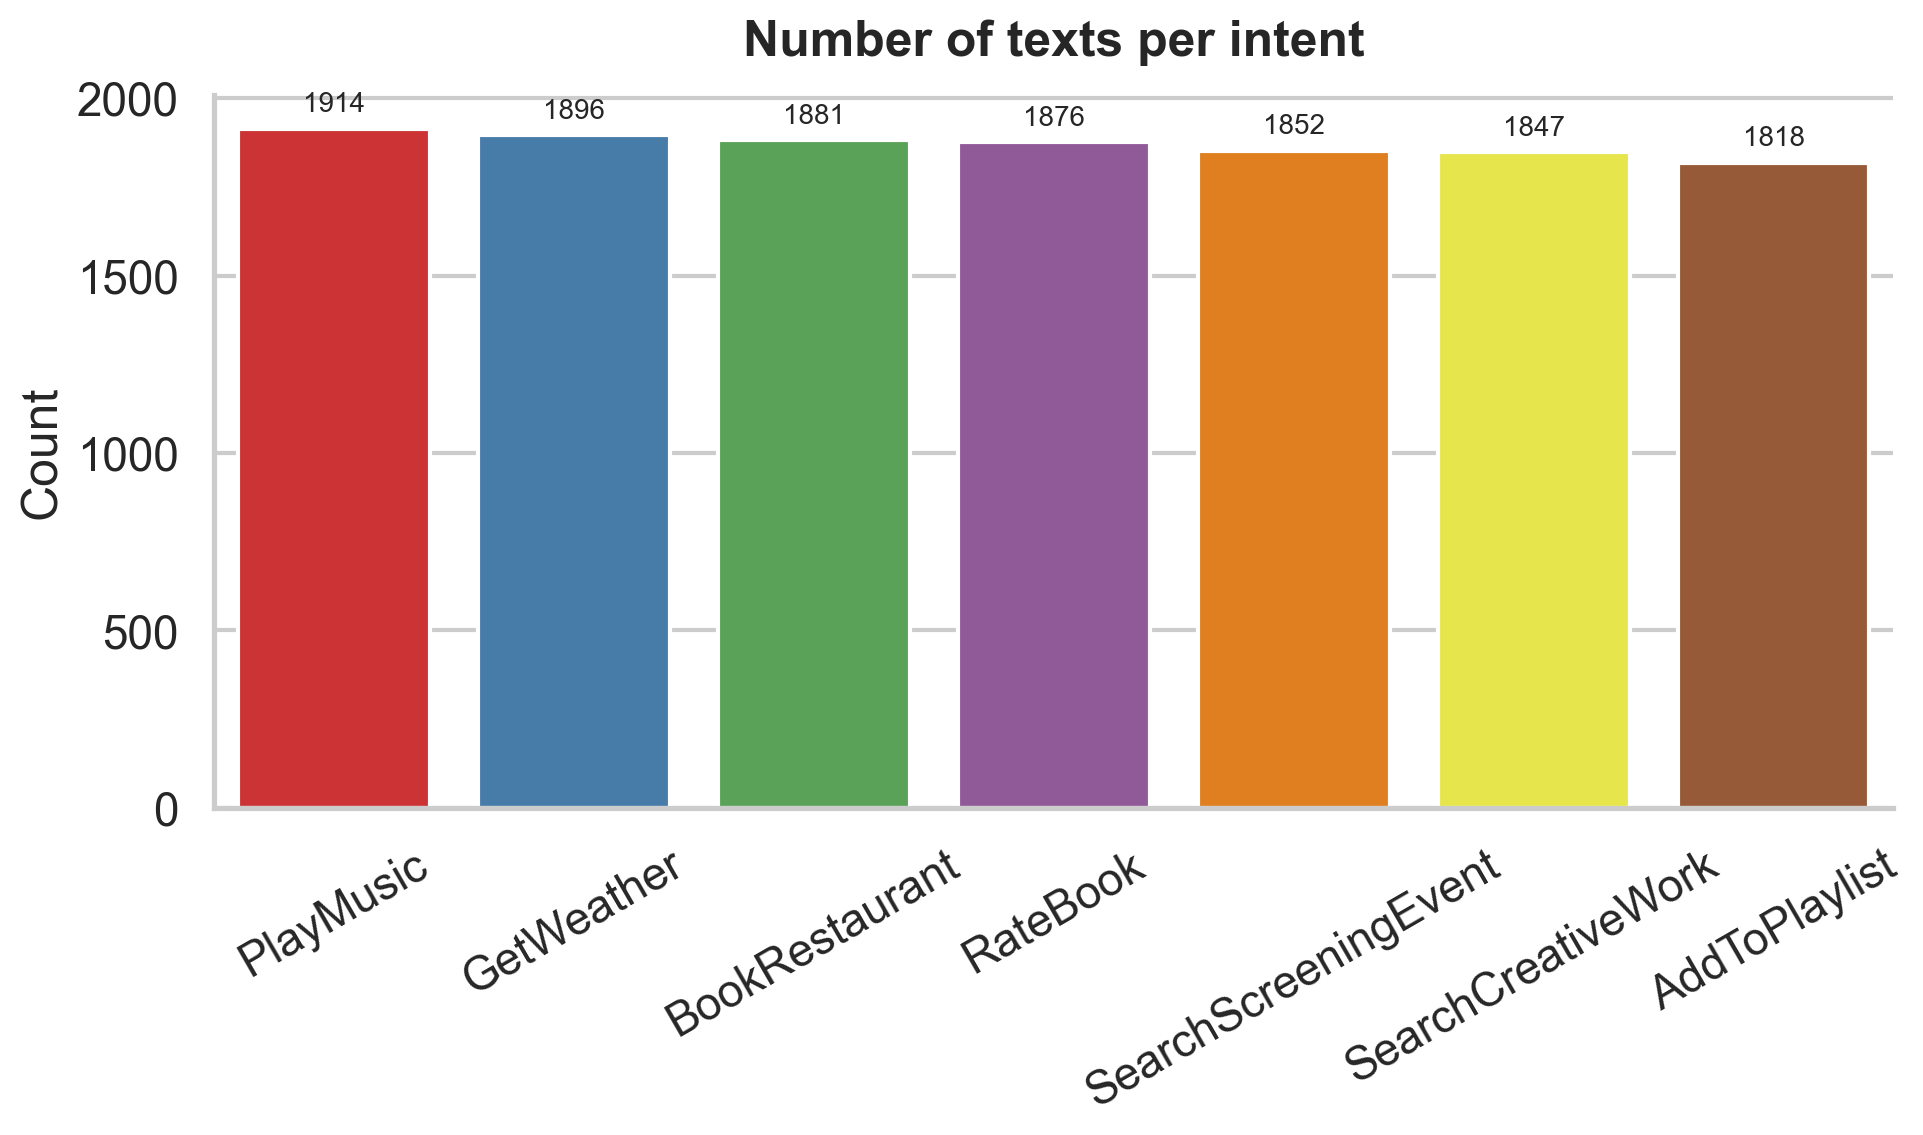

In [ ]:
sns.set_theme(style="whitegrid", context="talk")  # clean grid + larger fonts [12][18]

fig, ax = plt.subplots(figsize=(10, 6))  # room for labels [2]

order = train.intent.value_counts().index  # frequency-sorted categories [2]

chart = sns.countplot(
    x="intent",
    data=train,
    order=train.intent.value_counts().index,
    palette="Set1"
)


ax.set_title("Number of texts per intent", pad=14, weight="bold")  # clearer hierarchy [2]
ax.set_xlabel("")  # often redundant for categorical x [2]
ax.set_ylabel("Count")  # explicit y label [2]

# 5) Rotate and align tick labels for readability
ax.tick_params(axis='x', labelrotation=30)  # safer than set_xticklabels for rotation [10][7]

# 6) Add data labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points"
    )  # unobtrusive value labels [2]

# 7) Subtle style tweaks: thinner spines, tighter layout
sns.despine(ax=ax)  # remove top/right spines [15]
plt.tight_layout()  # prevent clipping [2]
plt.show()


                                                    text              intent  \
0       listen to westbam alumb allergic on google music           PlayMusic   
1             add step to me to the 50 clásicos playlist       AddToPlaylist   
2      i give this current textbook a rating value of...            RateBook   
3                   play the song little robin redbreast           PlayMusic   
4      please add iris dement to my playlist this is ...       AddToPlaylist   
...                                                  ...                 ...   
13079      i want to eat choucroute at a brasserie for 8      BookRestaurant   
13080                            play funky heavy bluesy           PlayMusic   
13081           rate the current album 2 points out of 6            RateBook   
13082             go to the photograph the inflated tear  SearchCreativeWork   
13083                     rate richard carvel 4 out of 6            RateBook   

       length  
0           8  
1      

array([[<Axes: title={'center': 'length'}>]], dtype=object)

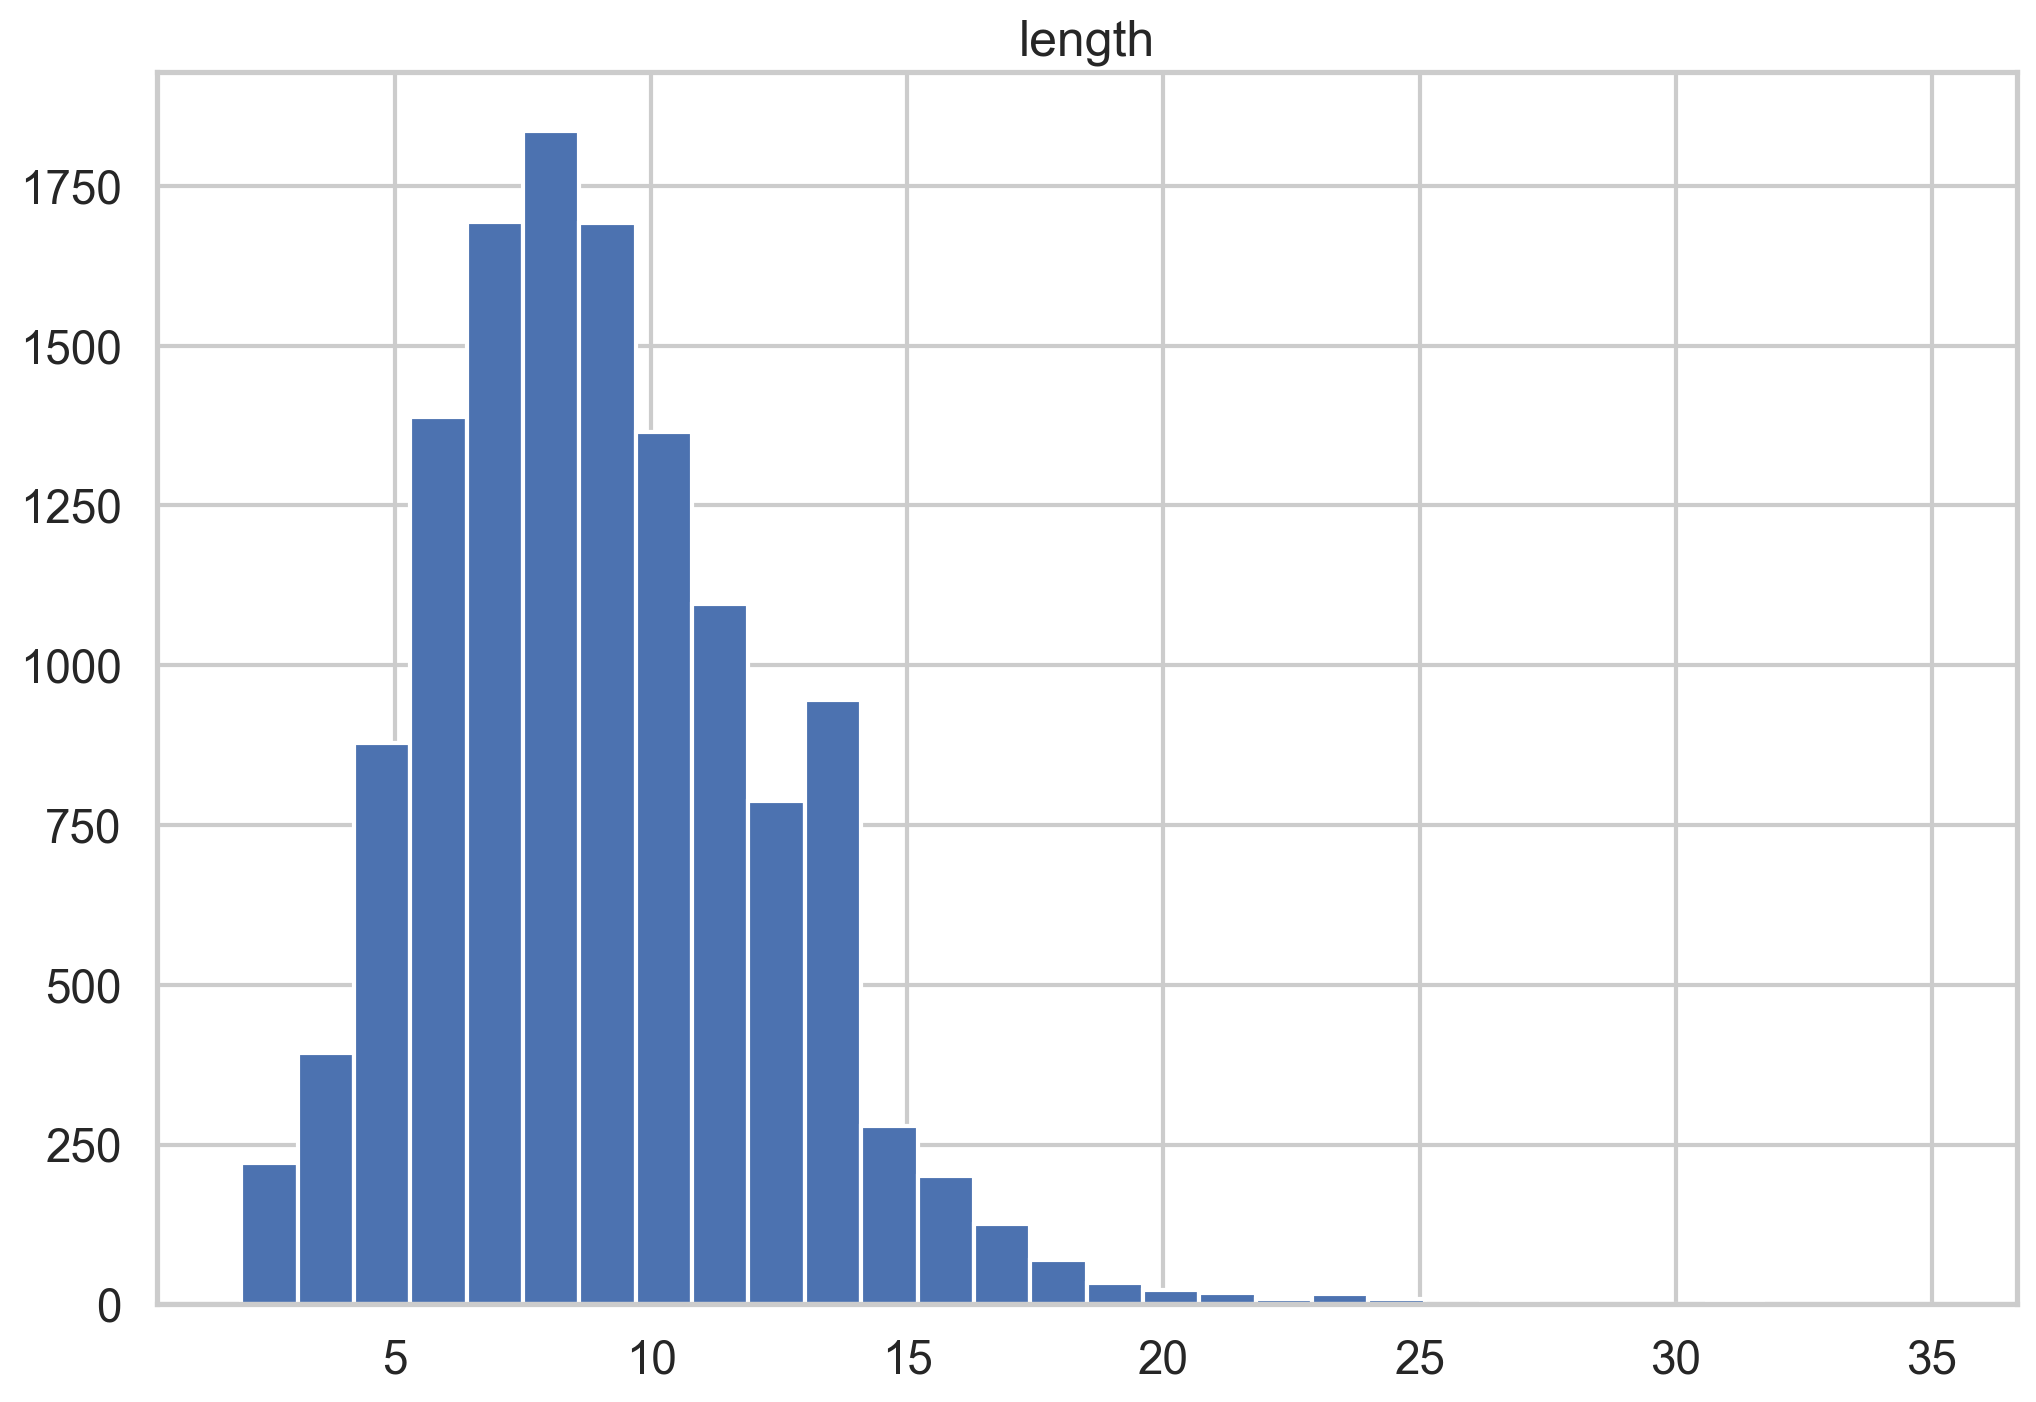

In [19]:
train["length"] = train["text"].str.split().str.len()

print(train)

train.hist('length', bins=30)
